# Trains and compares YOLO26n/s/m-det on the final caries-detection dataset (Dataset Tratado 3). Generates article Table 4 (hyperparameters), Table 13 (variant comparison), Figure 8/10 (training curves, confusion matrices, PR curves).

Same structure as the segmentation pipeline:
trains the three variants using the same protocol, generates the same curves
and tables for the paper (Section 3.3), and finally saves **all three**
`best.pt` files to Drive—not just the winner—as requested for
full traceability.

Input dataset: `Dataset-Caries-Balanced/data.yaml` (generated by
`Tratado_3_dataset_Shweta.md`, corrected: 1,459 images, 4,051 boxes,
223 negatives, 15.3%).

## CELL 0 — Environment Check and Installation



In [ ]:
import subprocess
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv"],
                      capture_output=True, text=True).stdout)

name, memory.total [MiB]
Tesla T4, 15360 MiB



In [ ]:
!pip install -q ultralytics

from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.5 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
import os
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
from ultralytics import YOLO

print("CUDA disponible:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "ninguna — revisa el entorno de ejecución")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA disponible: True
GPU: Tesla T4


## CELL 1 — Route Configuration


In [ ]:
BASE = Path("/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES")
DATASET_ROOT = BASE / "Dataset Tratado 3"
DATA_YAML = DATASET_ROOT / "data.yaml"

RUNS_DRIVE = BASE / "runs_deteccion_caries"     # resultados de cada variante se guardan aquí
RUNS_DRIVE.mkdir(parents=True, exist_ok=True)

# Final models folder
MODELOS_DRIVE = Path("/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO CARIES")
MODELOS_DRIVE.mkdir(parents=True, exist_ok=True)

# Carpeta de gráficos/tablas para el artículo (equivalente a lo generado en segmentación)
FIGURAS_DRIVE = BASE / "figuras_deteccion_caries"
FIGURAS_DRIVE.mkdir(parents=True, exist_ok=True)

assert DATA_YAML.exists(), f"No se encontró {DATA_YAML}"
print("data.yaml:", DATA_YAML)
print(DATA_YAML.read_text())

CLASS_NAMES = ["Caries"]  # una sola clase, confirmado en Correc1

data.yaml: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 3/data.yaml
train: images/train
val: images/val
test: images/test

nc: 1
names: ['Caries']



## CELL 2 — Quickly verify the dataset before training


In [ ]:
for split in ["train", "val", "test"]:
    img_dir = DATASET_ROOT / "images" / split
    lbl_dir = DATASET_ROOT / "labels" / split
    n_img = len(list(img_dir.glob("*")))
    n_lbl = len(list(lbl_dir.glob("*.txt")))
    n_vacios = sum(1 for f in lbl_dir.glob("*.txt") if f.stat().st_size == 0)
    print(f"{split}: {n_img} imágenes, {n_lbl} archivos de etiqueta ({n_vacios} vacíos/negativos)")

train: 1180 imágenes, 1180 archivos de etiqueta (183 vacíos/negativos)
val: 242 imágenes, 242 archivos de etiqueta (34 vacíos/negativos)
test: 242 imágenes, 242 archivos de etiqueta (38 vacíos/negativos)


### CELL 2.5 — Analysis of the relative area of the bounding boxes (for 3.2.2)

In [ ]:
import numpy as np
import pandas as pd

areas_pct = []
descartadas = 0

for split in ["train", "val", "test"]:
    lbl_dir = DATASET_ROOT / "labels" / split
    for f in lbl_dir.glob("*.txt"):
        if f.stat().st_size == 0:
            continue  # negativa, sin cajas
        for linea in f.read_text().strip().splitlines():
            partes = linea.split()
            if len(partes) != 5:
                descartadas += 1
                continue
            _, xc, yc, w, h = map(float, partes)
            # They should already be filtered (0<w<=1, 0<h<=1, box shown in the image);
            # This validation is a safety check; it should not discard anything.
            if not (0 < w <= 1 and 0 < h <= 1):
                descartadas += 1
                continue
            areas_pct.append(w * h * 100)  # % del área de la imagen

areas_pct = np.array(areas_pct)

media = areas_pct.mean()
mediana = np.median(areas_pct)
q1, q3 = np.percentile(areas_pct, [25, 75])
p95 = np.percentile(areas_pct, 95)
pct_menor_1 = (areas_pct < 1.0).mean() * 100

print(f"Cuadros analizados: {len(areas_pct)}")
print(f"Descartados por formato inválido: {descartadas}")
print(f"Media:            {media:.3f} %")
print(f"Mediana:          {mediana:.3f} %")
print(f"RIC (Q1–Q3):      {q1:.3f} % – {q3:.3f} %")
print(f"Percentil 95:     {p95:.3f} %")
print(f"% de cajas < 1 %: {pct_menor_1:.1f} %")

# Guardar para no perder el cálculo y poder citarlo con exactitud en el artículo
df_areas = pd.DataFrame({
    "indicador": ["n_cajas", "media_pct", "mediana_pct", "q1_pct", "q3_pct", "p95_pct", "pct_menor_1pct"],
    "valor": [len(areas_pct), media, mediana, q1, q3, p95, pct_menor_1],
})
RUTA_AREAS = MODELOS_DRIVE / "area_relativa_cajas_caries.csv"
df_areas.to_csv(RUTA_AREAS, index=False)
print(f"\n📄 Guardado en: {RUTA_AREAS}")

Cuadros analizados: 4569
Descartados por formato inválido: 0
Media:            3.108 %
Mediana:          3.113 %
RIC (Q1–Q3):      2.463 % – 3.725 %
Percentil 95:     4.567 %
% de cajas < 1 %: 0.4 %

📄 Guardado en: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO CARIES/area_relativa_cajas_caries.csv


## CELL 3 — Common hyperparameters (Table 4 of the article)

Identical across all three variants except for `batch`, which is adjusted based on the
available GPU memory on the T4. If you run out of memory (`CUDA out of memory`),
reduce the batch size for the affected variant.


In [ ]:
EPOCHS = 150
PATIENCE = 30
IMGSZ = 640
OPTIMIZER = "AdamW"
LR0 = 0.001
LRF = 0.01
MOMENTUM = 0.937
WEIGHT_DECAY = 0.0005
SEED = 42

VARIANTES = {
    "yolo26n-det": {"weights": "yolo26n.pt", "batch": 32},
    "yolo26s-det": {"weights": "yolo26s.pt", "batch": 16},
    "yolo26m-det": {"weights": "yolo26m.pt", "batch": 8},
}

print("Configuración por variante:")
for nombre, cfg in VARIANTES.items():
    print(f"  {nombre}: pesos={cfg['weights']}, batch={cfg['batch']}, epochs={EPOCHS}, "
          f"imgsz={IMGSZ}, patience={PATIENCE}, lr0={LR0}, pretrained=True")

Configuración por variante:
  yolo26n-det: pesos=yolo26n.pt, batch=32, epochs=150, imgsz=640, patience=30, lr0=0.001, pretrained=True
  yolo26s-det: pesos=yolo26s.pt, batch=16, epochs=150, imgsz=640, patience=30, lr0=0.001, pretrained=True
  yolo26m-det: pesos=yolo26m.pt, batch=8, epochs=150, imgsz=640, patience=30, lr0=0.001, pretrained=True


## CELL 4 — Training the Three Variants

Each model starts with pretrained weights on COCO (`pretrained=True`),
as defined in Section 2.4.2 of the paper. The results of each run
(weights, `results.csv`, confusion matrix, PR curve) are automatically saved to Drive
via `project=RUNS_DRIVE`.


In [ ]:
resultados_entrenamiento = {}

for nombre, cfg in VARIANTES.items():
    print(f"\n{'='*60}\nEntrenando {nombre}\n{'='*60}")
    t0 = time.time()

    modelo = YOLO(cfg["weights"])
    resultado = modelo.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        patience=PATIENCE,
        imgsz=IMGSZ,
        batch=cfg["batch"],
        optimizer=OPTIMIZER,
        lr0=LR0,
        lrf=LRF,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY,
        cos_lr=True,
        seed=SEED,
        pretrained=True,
        device=0,
        project=str(RUNS_DRIVE),
        name=nombre,
        exist_ok=True,
        plots=True,
        verbose=True,
    )

    tiempo_entrenamiento = time.time() - t0
    save_dir = Path(resultado.save_dir)
    resultados_entrenamiento[nombre] = {
        "modelo": modelo,
        "resultado_train": resultado,
        "tiempo_entrenamiento_s": tiempo_entrenamiento,
        "save_dir": save_dir,
        "ruta_pesos_best": save_dir / "weights" / "best.pt",
        "ruta_pesos_last": save_dir / "weights" / "last.pt",
    }
    print(f"\n{nombre} entrenado en {tiempo_entrenamiento/60:.1f} min. "
          f"Pesos guardados en: {resultados_entrenamiento[nombre]['ruta_pesos_best']}")


Entrenando yolo26n-det
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mod

In [ ]:
from pathlib import Path

resultados_entrenamiento = {
    "yolo26n-det": {"save_dir": RUNS_DRIVE / "yolo26n-det"},
    "yolo26s-det": {"save_dir": RUNS_DRIVE / "yolo26s-det"},
    "yolo26m-det": {"save_dir": RUNS_DRIVE / "yolo26m-det"},
}


## CELL 5 — Training Curves by Metric (loss, mAP50, precision, recall)

Generates the same type of graph as Cell C in the
segmentation pipeline, but with one figure for each of the three metrics.


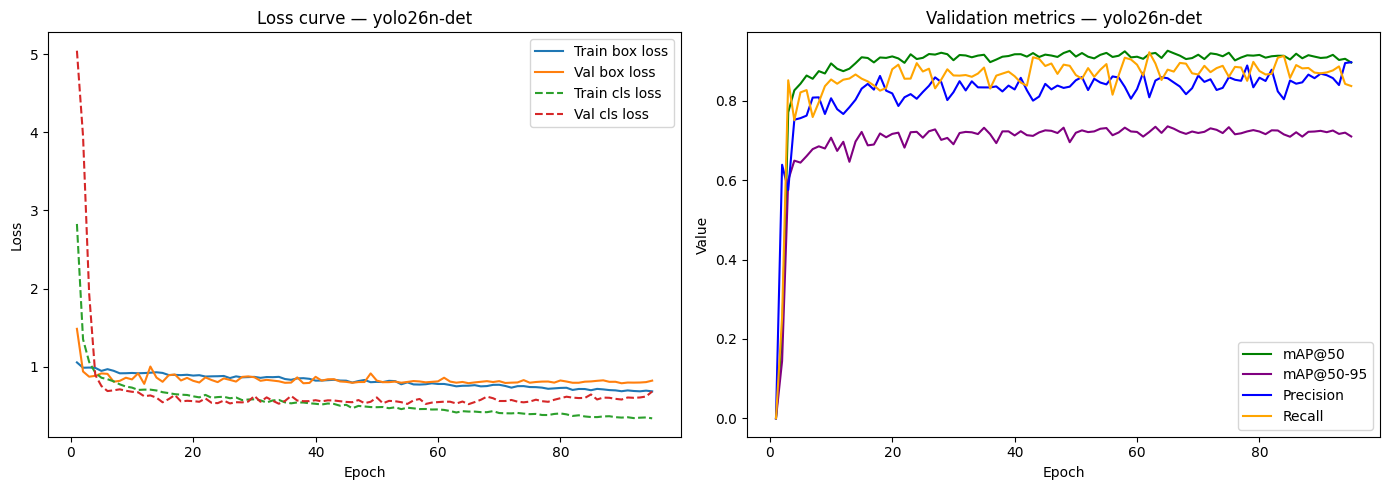

Saved: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/figuras_deteccion_caries/curvas_entrenamiento_yolo26n-det_EN.png


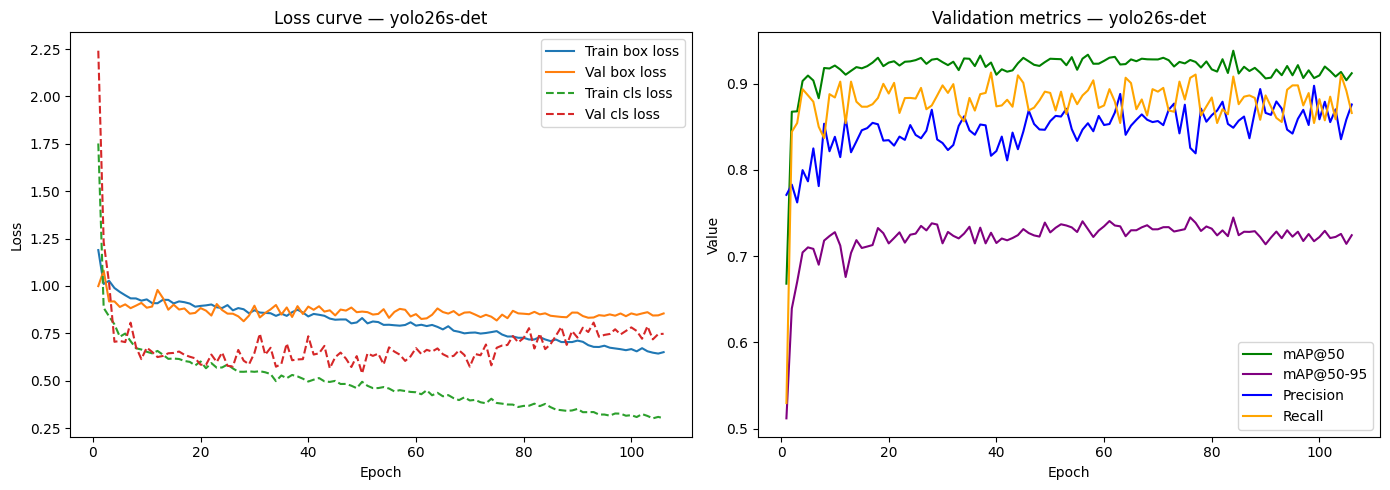

Saved: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/figuras_deteccion_caries/curvas_entrenamiento_yolo26s-det_EN.png


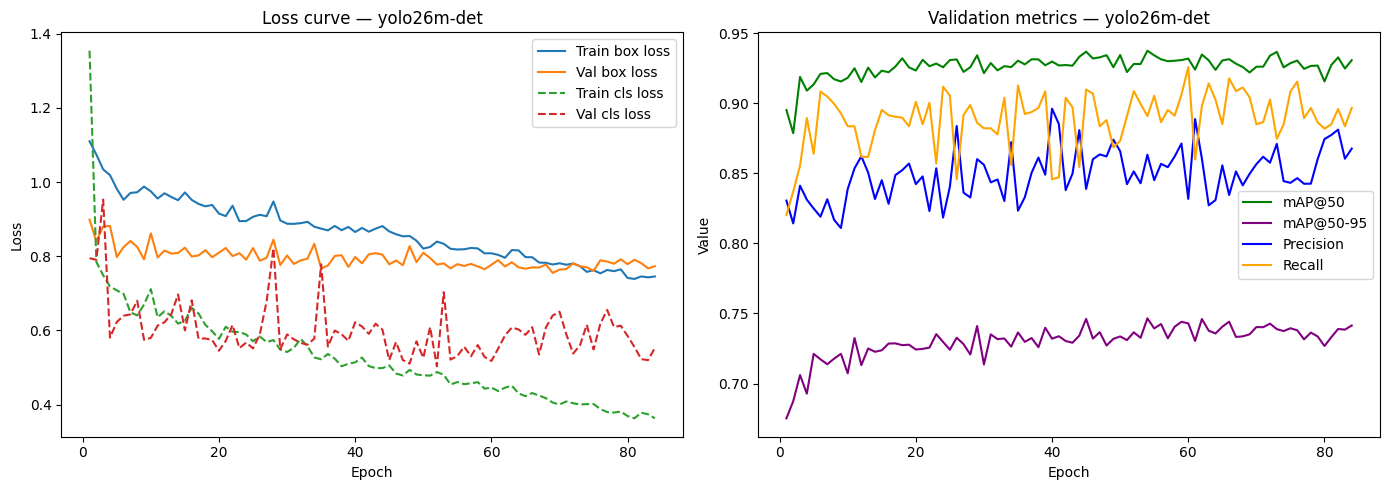

Saved: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/figuras_deteccion_caries/curvas_entrenamiento_yolo26m-det_EN.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

for name, data in resultados_entrenamiento.items():
    results_csv = data["save_dir"] / "results.csv"
    if not results_csv.exists():
        print(f"⚠️ {results_csv} not found, skipping {name}")
        continue

    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(df["epoch"], df["train/box_loss"], label="Train box loss")
    axes[0].plot(df["epoch"], df["val/box_loss"], label="Val box loss")
    if "train/cls_loss" in df.columns:
        axes[0].plot(df["epoch"], df["train/cls_loss"], label="Train cls loss", linestyle="--")
        axes[0].plot(df["epoch"], df["val/cls_loss"], label="Val cls loss", linestyle="--")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"Loss curve — {name}")
    axes[0].legend()

    axes[1].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@50", color="green")
    axes[1].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@50-95", color="purple")
    axes[1].plot(df["epoch"], df["metrics/precision(B)"], label="Precision", color="blue")
    axes[1].plot(df["epoch"], df["metrics/recall(B)"], label="Recall", color="orange")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Value")
    axes[1].set_title(f"Validation metrics — {name}")
    axes[1].legend()

    plt.tight_layout()
    out_path = FIGURAS_DRIVE / f"curvas_entrenamiento_{name}_EN.png"
    plt.savefig(out_path, dpi=200)
    plt.show()
    print(f"Saved: {out_path}")


## CELL 6 — Evaluation of the three variants on the TEST dataset

The evaluation is performed explicitly using `split=“test”` (not to be confused with the
validation metrics reported during training), just as in section 3.5 of the
article.


In [ ]:
metricas_por_variante = []
filas_confusion = []  # TP/FP/FN por variante, para la tabla que ya usabas

for nombre, datos in resultados_entrenamiento.items():
    print(f"\nEvaluando {nombre} sobre el conjunto de prueba...")
    modelo_best = YOLO(str(datos["ruta_pesos_best"]))

    # --- 1) val() SIN fijar conf: para mAP50/mAP50-95/precisión/recall
    #     "oficiales" (promediados sobre todos los umbrales de confianza,
    #     igual que se reporta en la Tabla 11 del artículo) ---
    metrics = modelo_best.val(data=str(DATA_YAML), split="test", imgsz=IMGSZ, device=0,
                               plots=False, save_json=False)

    n_params = sum(p.numel() for p in modelo_best.model.parameters())
    size_mb = datos["ruta_pesos_best"].stat().st_size / (1024 * 1024)

    fila = {
        "variante": nombre,
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map),
        "inferencia_ms": round(metrics.speed.get("inference", 0), 2),
        "tiempo_entrenamiento_min": round(datos["tiempo_entrenamiento_s"] / 60, 1),
        "n_parametros": n_params,
        "tamano_MB": round(size_mb, 2),
    }
    fila["f1"] = (2 * fila["precision"] * fila["recall"] / (fila["precision"] + fila["recall"])
                  if (fila["precision"] + fila["recall"]) > 0 else 0.0)
    metricas_por_variante.append(fila)

    # --- 2) val() CON conf=0.25: para la matriz de confusión y curva PR
    #     "reales" al punto de operación del pipeline, más TP/FP/FN ---
    metrics_conf025 = modelo_best.val(data=str(DATA_YAML), split="test", imgsz=IMGSZ, device=0,
                                       conf=0.25, plots=True, save_json=False)
    cm = metrics_conf025.confusion_matrix.matrix
    tp, fp, fn = float(cm[0, 0]), float(cm[0, 1]), float(cm[1, 0])
    print(f"  Matriz de confusión (conf=0.25) — {nombre}: TP={tp:.0f} FP={fp:.0f} FN={fn:.0f}")
    filas_confusion.append({"variante": nombre, "TP": tp, "FP": fp, "FN": fn})

    # Guardar matriz de confusión y curva PR de ESTA corrida (conf=0.25), no la de arriba
    val_save_dir = Path(metrics_conf025.save_dir)
    for fname in ["confusion_matrix.png", "confusion_matrix_normalized.png", "BoxPR_curve.png"]:
        src = val_save_dir / fname
        if src.exists():
            shutil.copy(src, FIGURAS_DRIVE / f"{fname.replace('.png', '')}_{nombre}.png")

df_metricas = pd.DataFrame(metricas_por_variante).sort_values("mAP50", ascending=False)
print("\n--- TABLA COMPARATIVA (equivalente a la Tabla 11 del artículo, detección) ---")
print(df_metricas.to_string(index=False))

df_metricas.round(4).to_csv(RUNS_DRIVE / "comparacion_variantes_deteccion_caries.csv", index=False)
df_metricas.round(4).to_csv(FIGURAS_DRIVE / "comparacion_variantes_deteccion_caries.csv", index=False)
print(f"\nGuardada en: {RUNS_DRIVE / 'comparacion_variantes_deteccion_caries.csv'}")

df_confusion = pd.DataFrame(filas_confusion)
print("\n--- TP / FP / FN por variante (conf=0.25) ---")
print(df_confusion.to_string(index=False))
df_confusion.to_csv(FIGURAS_DRIVE / "tp_fp_fn_por_variante_conf025.csv", index=False)
print(f"Guardada en: {FIGURAS_DRIVE / 'tp_fp_fn_por_variante_conf025.csv'}")


Evaluando yolo26n-det sobre el conjunto de prueba...
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.9±0.6 ms, read: 18.6±40.9 MB/s, size: 273.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 3/labels/test... 242 images, 38 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 242/242 115.8it/s 2.1s
val: New cache created: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 3/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.7it/s 6.0s
                   all        242        693      0.868      0.896      0.927  

## CELL 7 — Confusion matrices and PR curves for the three variants (mosaic)


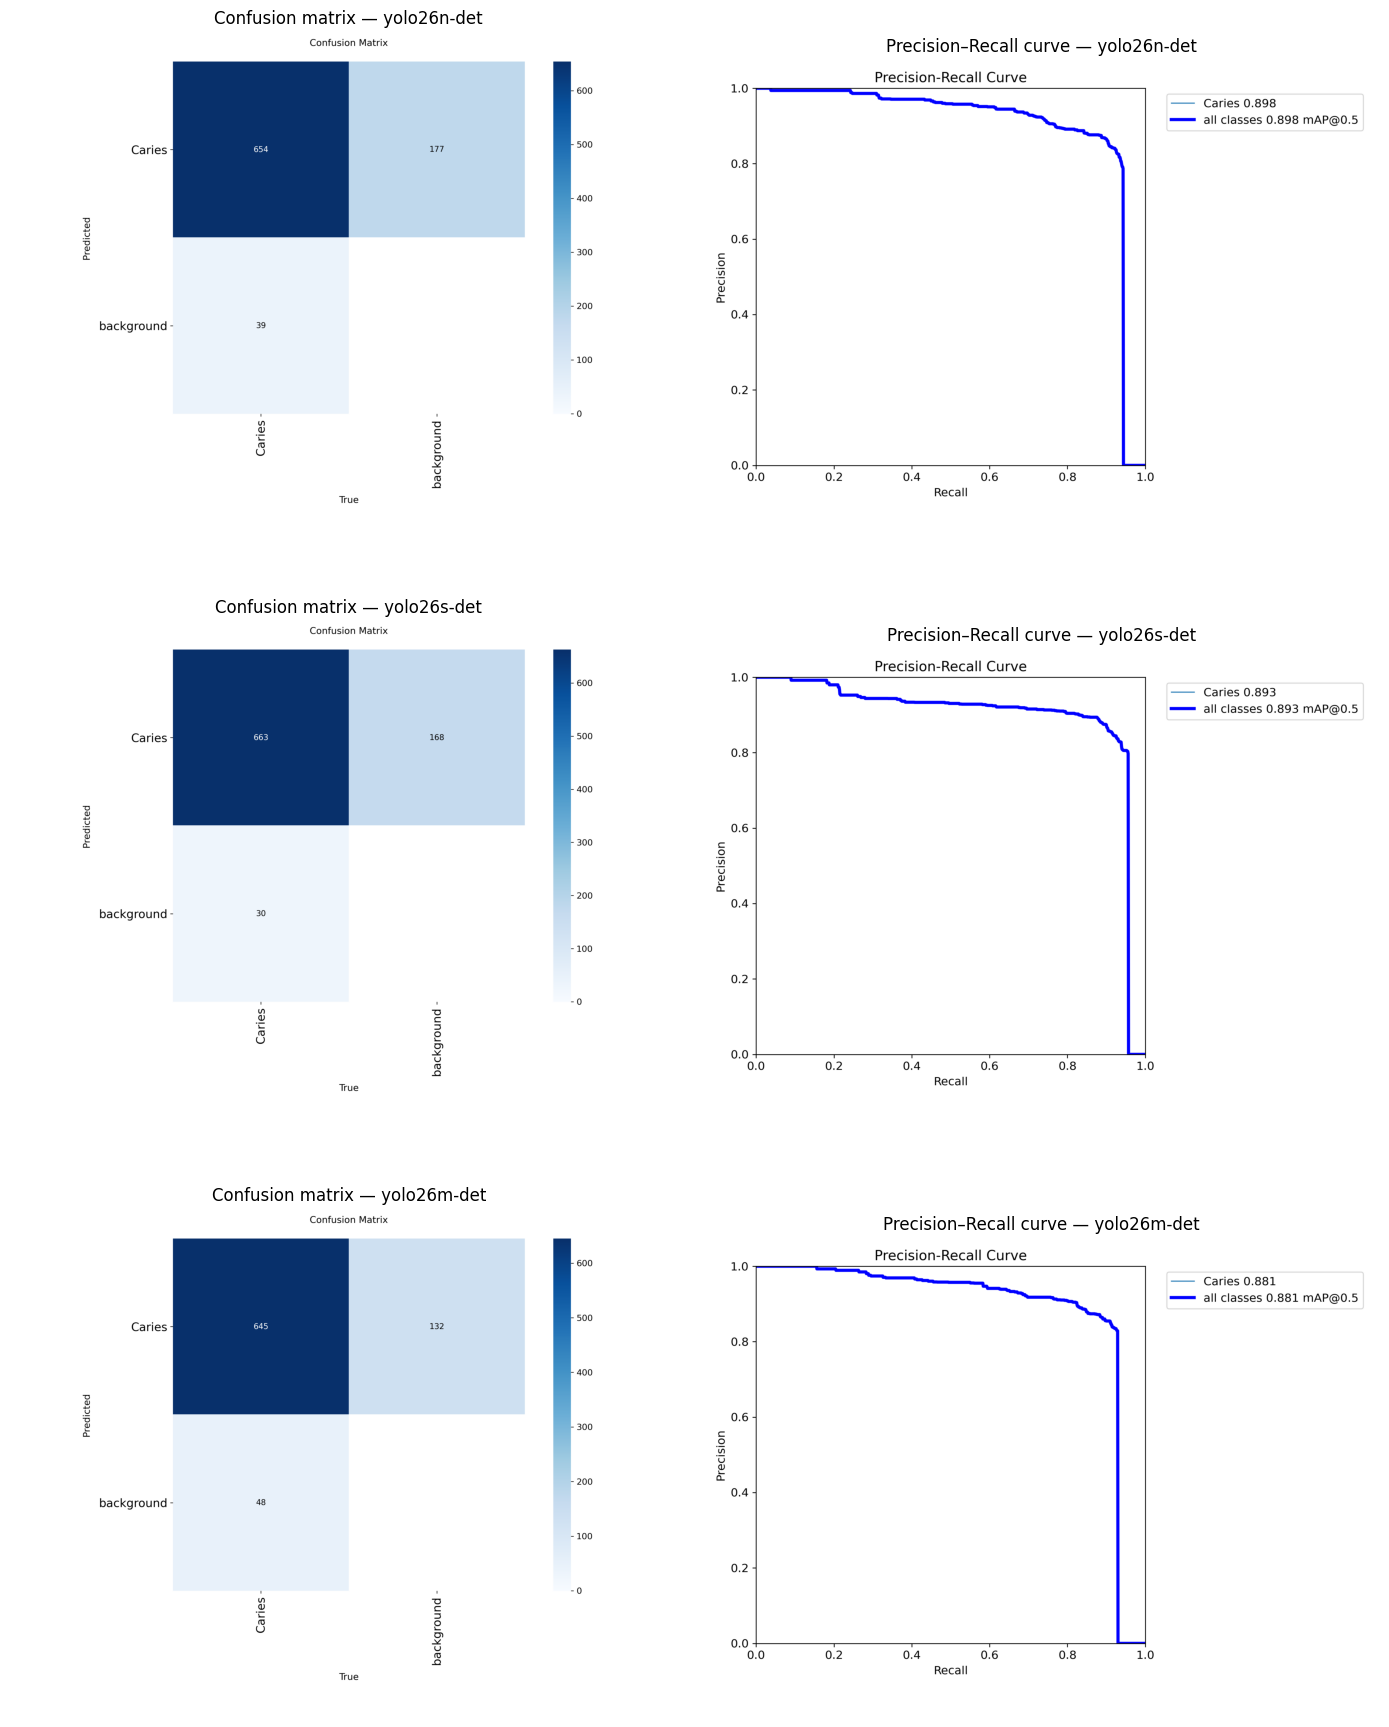

Saved: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/figuras_deteccion_caries/mosaico_confusion_pr_tres_variantes_EN.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(len(resultados_entrenamiento), 2, figsize=(14, 6 * len(resultados_entrenamiento)))
if len(resultados_entrenamiento) == 1:
    axes = [axes]

for row, name in zip(axes, resultados_entrenamiento.keys()):
    cm_path = FIGURAS_DRIVE / f"confusion_matrix_{name}.png"
    pr_path = FIGURAS_DRIVE / f"BoxPR_curve_{name}.png"
    if cm_path.exists():
        row[0].imshow(mpimg.imread(cm_path)); row[0].axis("off")
        row[0].set_title(f"Confusion matrix — {name}")
    if pr_path.exists():
        row[1].imshow(mpimg.imread(pr_path)); row[1].axis("off")
        row[1].set_title(f"Precision–Recall curve — {name}")

plt.tight_layout()
out_path = FIGURAS_DRIVE / "mosaico_confusion_pr_tres_variantes_EN.png"
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Saved: {out_path}")


## CELL 8 — Final Comparative Chart (Metrics + Computational Cost)

Same type of chart as the optional cell in the segmentation pipeline,
but calculated directly based on the three variants already trained in this
same run (it does not depend on a CSV file shared between separate notebooks).


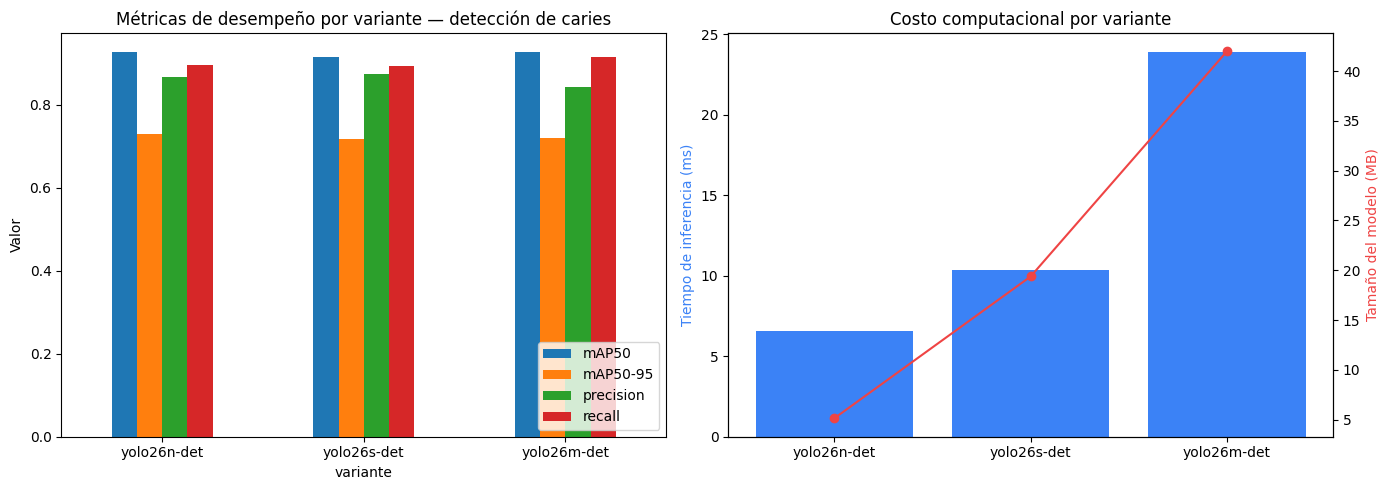

Guardado: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/figuras_deteccion_caries/comparacion_final_deteccion_caries.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df_metricas.set_index("variante").loc[["yolo26n-det", "yolo26s-det", "yolo26m-det"]].reset_index()

df_plot.plot(x="variante", y=["mAP50", "mAP50-95", "precision", "recall"], kind="bar", ax=axes[0])
axes[0].set_title("Métricas de desempeño por variante — detección de caries")
axes[0].set_ylabel("Valor")
axes[0].legend(loc="lower right")
axes[0].tick_params(axis="x", rotation=0)

ax2 = axes[1]
ax2.bar(df_plot["variante"], df_plot["inferencia_ms"], color="#3b82f6")
ax2.set_ylabel("Tiempo de inferencia (ms)", color="#3b82f6")
ax2b = ax2.twinx()
ax2b.plot(df_plot["variante"], df_plot["tamano_MB"], color="#ef4444", marker="o")
ax2b.set_ylabel("Tamaño del modelo (MB)", color="#ef4444")
axes[1].set_title("Costo computacional por variante")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
out_path = FIGURAS_DRIVE / "comparacion_final_deteccion_caries.png"
plt.savefig(out_path, dpi=200)
plt.show()
print(f"Guardado: {out_path}")

## CELL 9 — Selecting the Final Model


In [ ]:
mejor_variante = df_metricas.iloc[0]["variante"]
mejor_datos = resultados_entrenamiento[mejor_variante]
mejor_ruta_pesos = mejor_datos["ruta_pesos_best"]

print(f"Modelo seleccionado (mayor mAP@50): {mejor_variante}")
print(df_metricas[df_metricas["variante"] == mejor_variante].to_string(index=False))
print(f"Pesos: {mejor_ruta_pesos}")

Modelo seleccionado (mayor mAP@50): yolo26m-det
   variante  precision   recall    mAP50  mAP50-95  inferencia_ms  tiempo_entrenamiento_min  n_parametros  tamano_MB       f1
yolo26m-det   0.843464 0.914863 0.927057  0.720869          23.88                     102.0      20350223      41.99 0.877714
Pesos: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/runs_deteccion_caries/yolo26m-det/weights/best.pt


## CELL 10 — Save ALL THREE trained models to Drive (CARIES MODEL)

Save `best.pt` and `last.pt` for all **three** variants (not just the
winning one), the comparison table, the `data.yaml` file used, and a copy of the
selected model with a fixed name so it can be easily referenced in the
geometric association notebook (section 2.4.3 of the article).


In [ ]:
for nombre, datos in resultados_entrenamiento.items():
    origen_best = datos["ruta_pesos_best"]
    origen_last = datos["ruta_pesos_last"]

    if origen_best.exists():
        destino_best = MODELOS_DRIVE / f"{nombre}_best.pt"
        shutil.copy(origen_best, destino_best)
        print(f"✅ {nombre}: best.pt copiado a {destino_best}")
    else:
        print(f"⚠️ {nombre}: no se encontró {origen_best}")

    if origen_last.exists():
        destino_last = MODELOS_DRIVE / f"{nombre}_last.pt"
        shutil.copy(origen_last, destino_last)

# Copia adicional del modelo seleccionado con nombre fijo
shutil.copy(mejor_ruta_pesos, MODELOS_DRIVE / "modelo_deteccion_final.pt")
print(f"\n🏆 Modelo seleccionado ({mejor_variante}) copiado también como: "
      f"{MODELOS_DRIVE / 'modelo_deteccion_final.pt'}")

# Tabla comparativa y configuración usada, para reproducibilidad
df_metricas.round(4).to_csv(MODELOS_DRIVE / "comparacion_variantes_deteccion_caries.csv", index=False)
shutil.copy(DATA_YAML, MODELOS_DRIVE / "data.yaml")

print(f"\n📁 Contenido final de {MODELOS_DRIVE}:")
for f in sorted(MODELOS_DRIVE.iterdir()):
    print(" -", f.name)

✅ yolo26n-det: best.pt copiado a /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO CARIES/yolo26n-det_best.pt
✅ yolo26s-det: best.pt copiado a /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO CARIES/yolo26s-det_best.pt
✅ yolo26m-det: best.pt copiado a /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO CARIES/yolo26m-det_best.pt

🏆 Modelo seleccionado (yolo26m-det) copiado también como: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO CARIES/modelo_deteccion_final.pt

📁 Contenido final de /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO CARIES:
 - area_relativa_cajas_caries.csv
 - comparacion_variantes_deteccion_caries.csv
 - data.yaml
 - modelo_deteccion_final.pt
 - yolo26m-det_best.pt
 - yolo26m-det_last.pt
 - yolo26n-det_best.pt
 - yolo26n-det_last.pt
 - yolo26s-det_best.pt
 - yolo26s-det_last.pt


## CELL 11 — Inference and Visualization Using Drive Images (Selected Model)


In [ ]:
from IPython.display import Image, display
import glob

test_imgs = [
    '/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/IMAGENES PRUEBA/IMG1.jpeg',
    '/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/IMAGENES PRUEBA/IMG2.jpeg'
]

modelo_final = YOLO(str(MODELOS_DRIVE / "modelo_deteccion_final.pt"))
results_pred = modelo_final.predict(
    source=test_imgs,
    save=True,
    project='runs/prueba_deteccion',
    name=f'imagenes_prueba_{mejor_variante}',
    conf=0.25,
    device='cuda:0'
)

print(f"🦷 Predicciones del modelo {mejor_variante}:\n")
pred_imgs = sorted(glob.glob(f'runs/prueba_deteccion/imagenes_prueba_{mejor_variante}/*'))
for img_path in pred_imgs:
    print(f"📸 {img_path.split('/')[-1]}")
    display(Image(img_path, width=700))


0: 448x640 (no detections), 26.3ms
1: 448x640 2 Cariess, 26.3ms
Speed: 3.4ms preprocess, 26.3ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/runs/prueba_deteccion/imagenes_prueba_yolo26m-det
🦷 Predicciones del modelo yolo26m-det:



## CELL 12 — Markdown to insert Table 13 into the article (3.3.2)


In [ ]:
print(df_metricas.round(4).to_markdown(index=False))

| variante    |   precision |   recall |   mAP50 |   mAP50-95 |   inferencia_ms |   tiempo_entrenamiento_min |   n_parametros |   tamano_MB |     f1 |
|:------------|------------:|---------:|--------:|-----------:|----------------:|---------------------------:|---------------:|------------:|-------:|
| yolo26m-det |      0.8435 |   0.9149 |  0.9271 |     0.7209 |           23.88 |                      102   |       20350223 |       41.99 | 0.8777 |
| yolo26n-det |      0.8676 |   0.8961 |  0.9265 |     0.7285 |            6.56 |                       66.8 |        2375031 |        5.14 | 0.8816 |
| yolo26s-det |      0.8744 |   0.8937 |  0.9154 |     0.7172 |           10.32 |                       83.7 |        9465567 |       19.38 | 0.8839 |


## CELL 13 — Automatic shutdown of the runtime when everything is finished


In [ ]:
import time

print("✅ Todas las celdas anteriores terminaron.")
print("Esperando 60s para asegurar que Drive termine de sincronizar los últimos archivos...")
time.sleep(60)

from google.colab import runtime
print("Desconectando runtime ahora.")
runtime.unassign()

✅ Todas las celdas anteriores terminaron.
Esperando 60s para asegurar que Drive termine de sincronizar los últimos archivos...
Desconectando runtime ahora.


## Summary of what is produced after running this pipeline

- `RUNS_DRIVE` (`runs_deteccion_caries/`): complete Ultralytics run
  by variant (weights, `results.csv`, `confusion_matrix.png`, original PR curves,
  etc.) — useful if you need to review a specific detail later.
- `FIGURAS_DRIVE` (`figuras_deteccion_caries/`): training curves
  by variant, mosaic of confusion matrices + PR, final comparison
  chart, and CSV of metrics — ready to insert into the article (Figure 8,
  Figure 10, Table 11).
- `MODELOS_DRIVE` (`MODELO CARIES/`): the **three** `best.pt` files + `last.pt`,
  the winning model with a fixed name (`modelo_deteccion_final.pt`), the
  comparison table, and the `data.yaml` file used.